### Project 3 Checkpoint:

**Team Name**: Marine Metrics

**Team Members**: Natalie Huynh, Nikita Jain, Irina Vardapetyan

This project attempts to visualize monthly ocean data using historical surface tempuratures using the CMIP6 dataset with the following fields:

- **variable_id**: `tos`, Sea Surface Temperature in degrees Celsius
- **experiment_id**: `historical`, historical data
- **table_id**: `Omon`, Monthly Ocean Data
- **source_id (model)**: `MIROC6`, one of the working models

**Load Data**

In [2]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.4.0
    Uninstalling fsspec-2026.4.0:
      Successfully uninstalled fsspec-2026.4.0
  Attempting uninstall: zarr
    Found existing installation: zarr 3.2.0
    Uninstalling zarr-3.2.0:
      Successfully uninstalled zarr-3.2.0
  Attempting uninstall: gcsfs
    Found existing installation: gcsfs 2026.4.0
    Uninstalling gcsfs-2026.4.0:
      Successfully uninstalled gcsfs-2026.4.0

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [4]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


In [6]:
#interpreting variable ids
variables = pd.read_csv("data/cmip6_variables.csv")

#tos is the variable id for the sea surface temp affiliated with the table ids Omon (monthly ocean data)
variables[variables['variable_id'] == 'tos']

#other variable ids related to the sea:
sea_ocean_vars = variables[
    (variables["table_id(s)"] == "Omon") &
    (variables["description"].str.contains("sea|ocean", case=False, na=False))
]
sea_ocean_vars.to_csv("data/ocean_variables.csv")

In [7]:
#focusing on ocean data
ocean_data = df.query("table_id == 'Omon' & experiment_id == 'historical'")
fs = gcsfs.GCSFileSystem(token="anon")

tos_df = ocean_data[
    (ocean_data["variable_id"] == "tos") &
    (ocean_data["table_id"] == "Omon") &
    (ocean_data["experiment_id"] == "historical")
].drop_duplicates(subset="source_id")
tos_df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
995,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Omon,tos,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
9976,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,Omon,tos,gr,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180701
22198,CMIP,IPSL,IPSL-CM6A-LR,historical,r8i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,NaN,20180803
32357,CMIP,NASA-GISS,GISS-E2-1-G,historical,r1i1p1f1,Omon,tos,gn,gs://cmip6/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G/hi...,NaN,20180827
37663,CMIP,CNRM-CERFACS,CNRM-CM6-1,historical,r1i1p1f2,Omon,tos,gr1,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1/...,NaN,20180917


**Identifying Working Models**:

The below code determines that for tos_df, these are the models that work:

['GFDL-ESM4', 'GFDL-CM4', 'IPSL-CM6A-LR', 'GISS-E2-1-G', 'CNRM-CM6-1', 'BCC-CSM2-MR', 'BCC-ESM1', 'CNRM-ESM2-1', 'MIROC6', 'AWI-CM-1-1-MR', 'CESM2', 'SAM0-UNICON', 'GISS-E2-1-H', 'CanESM5', 'CanESM5-CanOE', 'INM-CM4-8', 'UKESM1-0-LL', 'INM-CM5-0', 'HadGEM3-GC31-LL', 'MPI-ESM-1-2-HAM', 'NESM3', 'CAMS-CSM1-0', 'MPI-ESM1-2-LR', 'MPI-ESM1-2-HR', 'MCM-UA-1-0', 'CESM2-WACCM', 'GISS-E2-1-G-CC', 'NorESM2-LM', 'MIROC-ES2L', 'E3SM-1-0', 'MRI-ESM2-0', 'NorCPM1', 'FGOALS-f3-L', 'CNRM-CM6-1-HR', 'FGOALS-g3', 'ACCESS-CM2', 'NorESM2-MM', 'ACCESS-ESM1-5', 'CESM2-FV2', 'CESM2-WACCM-FV2', 'FIO-ESM-2-0', 'E3SM-1-1', 'HadGEM3-GC31-MM', 'E3SM-1-1-ECA', 'KACE-1-0-G', 'EC-Earth3-Veg', 'EC-Earth3', 'AWI-ESM-1-1-LR', 'CIESM', 'CAS-ESM2-0', 'CMCC-CM2-SR5', 'EC-Earth3-AerChem', 'TaiESM1', 'IPSL-CM5A2-INCA', 'CMCC-CM2-HR4', 'IITM-ESM', 'EC-Earth3-Veg-LR', 'EC-Earth3-CC', 'CMCC-ESM2', 'IPSL-CM6A-LR-INCA']

In [7]:
# working_models = []

# for model in tos_df["source_id"].unique():
#     try:
#         row = tos_df[tos_df["source_id"] == model].iloc[0]
#         store = fs.get_mapper(row["zstore"])
#         ds = xr.open_zarr(store, consolidated=False)
#         _ = ds["tos"]
#         working_models.append(model)
#     except:
#         pass

# print(working_models)

**Preliminary Regional Stats**:
Coordinates are split based on the regions defined by the National Oceanography Centre.



Historical Data Captures records from 1850 up to the end of 2014. We average the stats over this timeline, and the

In [8]:
# load MIROC6 dataset
row = tos_df[tos_df["source_id"] == "MIROC6"].iloc[0]

store = fs.get_mapper(row["zstore"])
ds = xr.open_zarr(store, consolidated=False)

tos = ds["tos"]
print("dataset loaded")

# correct coordinate handling (MIROC6 uses 2D lat/lon fields)
lat = ds["latitude"]
lon = ds["longitude"]

# longitude standardization
if lon.max() > 180:
    lon = ((lon + 180) % 360) - 180
    ds["longitude"] = lon  # update dataset coord for consistency

# time slicing
tos_sub = tos.sel(time=slice("1990", "2015"))

mean_map = tos_sub.mean(dim="time").compute()
min_map = tos_sub.min(dim="time").compute()
max_map = tos_sub.max(dim="time").compute()

# convert gridded data -> flat dataframe (IMPORTANT for 2D grids)
df = mean_map.stack(points=("y", "x")).to_dataframe(name="mean_temp").reset_index()

# attach correct lat/lon values
df["lat"] = lat.stack(points=("y", "x")).values
df["lon"] = lon.stack(points=("y", "x")).values

# add min/max correctly aligned
df["min_temp"] = min_map.stack(points=("y", "x")).values
df["max_temp"] = max_map.stack(points=("y", "x")).values

# drop missing ocean points
df = df.dropna(subset=["mean_temp"])

# classifying ocean regions
def classify_ocean(lat, lon):
    # Arctic
    if lat > 66.5:
        return "Arctic Ocean"

    # Southern Ocean
    if lat < -55:
        if 20 <= lon < 160:
            return "Southern Ocean (East)"
        return "Southern Ocean (West)"

    # Indian Ocean
    if -55 <= lat <= 23.5:
        if 20 <= lon < 80:
            return "Indian Ocean (West)"
        if 80 <= lon < 120:
            return "Indian Ocean (East)"

    if -55 <= lat < -23.5:
        return "South Atlantic Ocean"
    
    # Atlantic Ocean (added lon bounds so Pacific is reachable)
    if -23.5 <= lat <= 23.5 and -80 <= lon < 20:
        return "Tropical Atlantic Ocean"

    if lat > 23.5 and -80 <= lon < -40:
        return "Northwest Atlantic Ocean"

    if lat > 23.5 and -40 <= lon < 20:
        return "Northeast Atlantic Ocean"

    if -55 <= lat < -23.5 and -80 <= lon < 20:
        return "South Atlantic Ocean"

    # Pacific Ocean
    if lat > 23.5:
        if lon < -80:
            return "Northeast Pacific Ocean"
        return "Northwest Pacific Ocean"

    if -23.5 <= lat <= 23.5:
        return "Tropical Pacific Ocean"

    if -55 <= lat < -23.5:
        return "South Pacific Ocean"

    return "Unclassified"

# region classification
df["region"] = df.apply(
    lambda r: classify_ocean(r["lat"], r["lon"]),
    axis=1
)

# stats
region_stats = df.groupby("region")["mean_temp"].agg([
    "min",
    "max",
    "mean"
])

region_stats

I0510 20:18:11.357598 3529527 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0510 20:18:11.366842 3529785 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(103, generation: 1)


dataset loaded


,min,max,mean
region,,,
Arctic Ocean,-1.769675,9.115611,-0.493051
Indian Ocean (East),3.842506,31.035830,21.785292
Indian Ocean (West),3.852350,30.142763,20.638517
Northeast Atlantic Ocean,0.231840,23.753590,14.167033
Northeast Pacific Ocean,0.337886,28.386286,12.879567
Northwest Atlantic Ocean,-0.394245,27.529190,13.627958
Northwest Pacific Ocean,2.742250,30.530329,13.932478
South Atlantic Ocean,4.225469,25.091017,14.338990
Southern Ocean (East),-1.288645,7.756694,2.318951


In [9]:
print(tos)
print(tos.dims)
print(tos.coords)

<xarray.DataArray 'tos' (time: 1980, y: 256, x: 360)> Size: 730MB
[182476800 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T...
  * y          (y) float64 2kB -88.0 -85.75 -85.25 -84.75 ... 148.6 150.5 152.4
  * x          (x) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    latitude   (y, x) float32 369kB ...
    longitude  (y, x) float32 369kB 60.5 61.5 62.5 63.5 ... 59.96 59.98 59.99
Attributes:
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    long_name:      Sea Surface Temperature
    original_name:  TO
    standard_name:  sea_surface_temperature
    units:          degC
('time', 'y', 'x')
Coordinates:
  * time       (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T...
  * y          (y) float64 2kB -88.0 -85.75 -85.25 -84.75 ... 148.6 150.5 152.4
  * x          

#### EDA # 3: Mapping the Hottest Ocean Regions Based on Coordinates (Using only MIROC6)

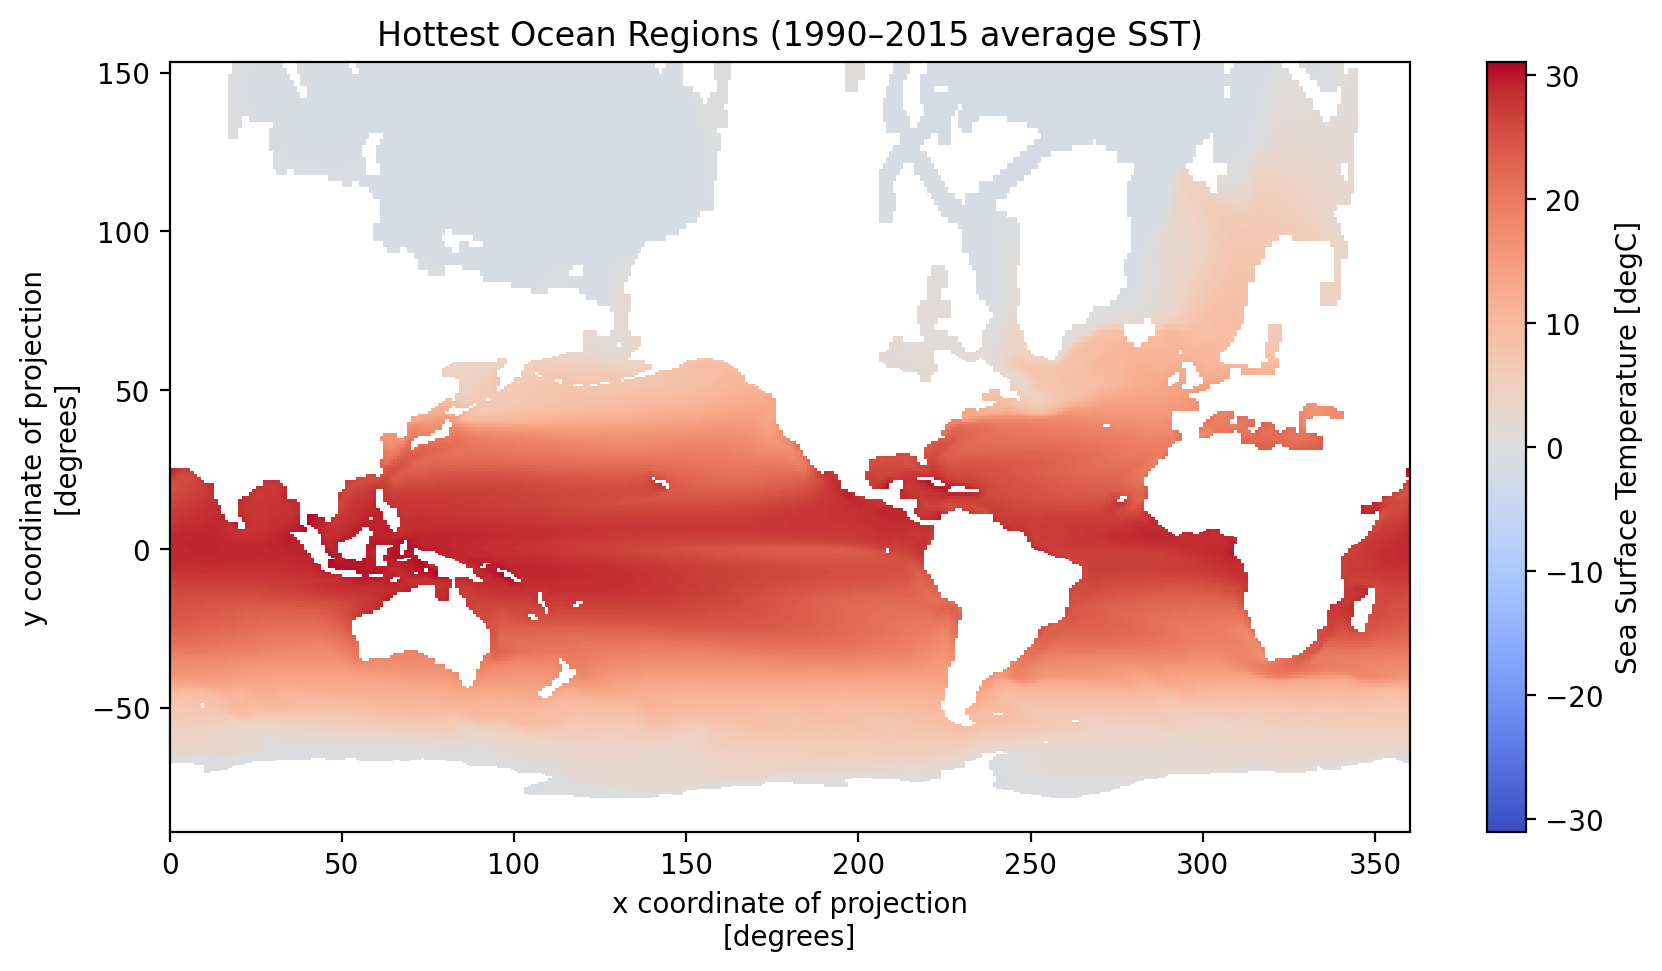

In [9]:
row = ocean_data[
    (ocean_data["source_id"] == "MIROC6") &
    (ocean_data["variable_id"] == "tos") &
    (ocean_data["table_id"] == "Omon") &
    (ocean_data["experiment_id"] == "historical")
].iloc[0]

store = fs.get_mapper(row["zstore"])
ds = xr.open_zarr(store, consolidated=False)

tos = ds["tos"]

mean_sst = tos.sel(time=slice("1990", "2014")).mean(dim="time").compute()

units = tos.attrs.get("units", "")
if "K" in units or mean_sst.values.mean() > 100:
    mean_sst = mean_sst - 273.15

plt.figure(figsize=(10, 5))
mean_sst.plot(cmap="coolwarm")
plt.title("Hottest Ocean Regions (1990–2015 average SST)")
plt.show()


#### EDA #4: Change In Temperature over Time in the Hottest Ocean Regions(Using only MIROC6)

dataset opened, now computing...


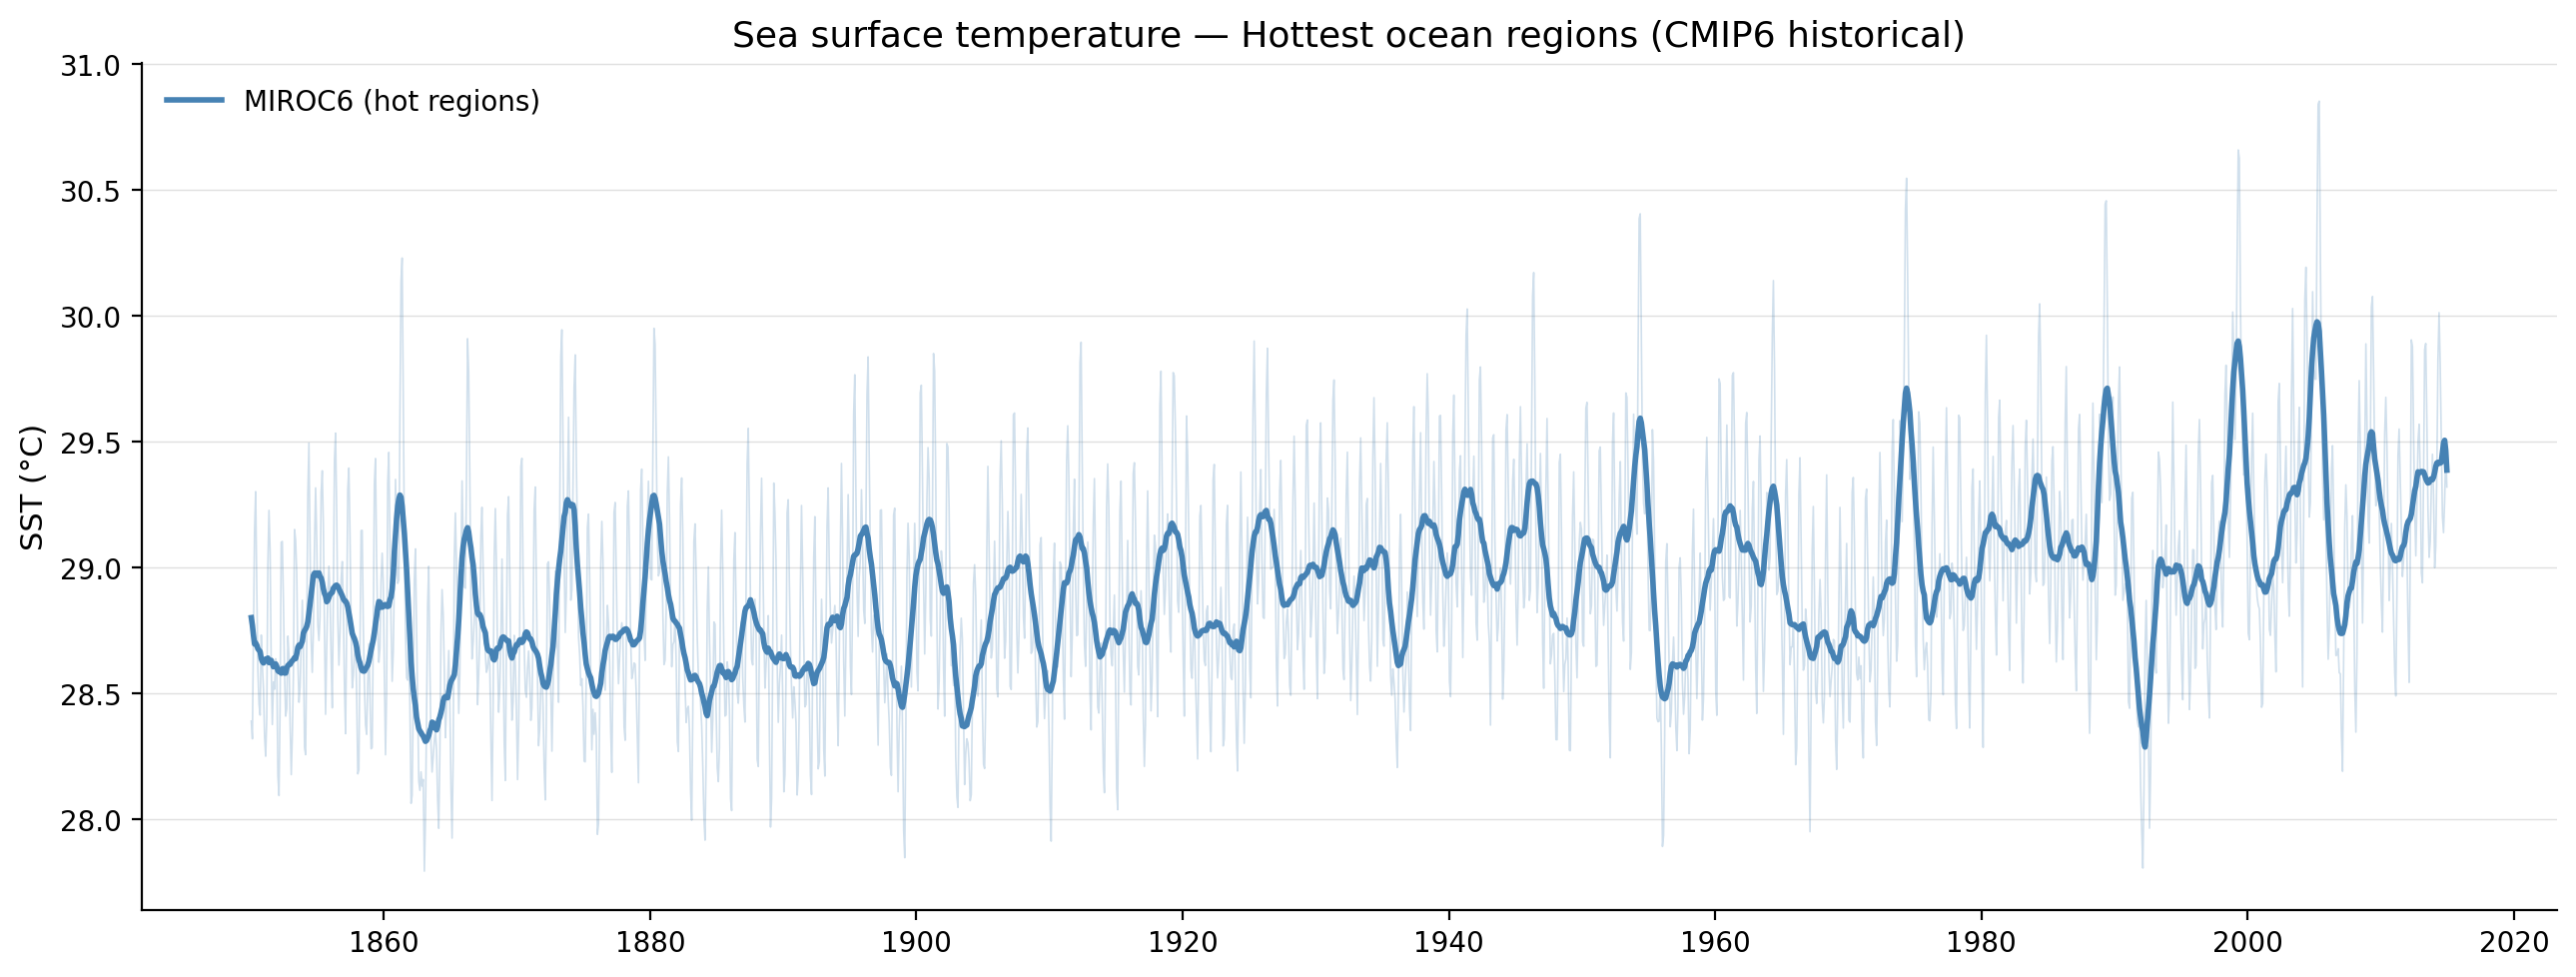

In [10]:
row = tos_df[tos_df["source_id"] == "MIROC6"].iloc[0]

store = fs.get_mapper(row["zstore"])
ds = xr.open_zarr(store, consolidated=False)

tos = ds["tos"]
print("dataset opened, now computing...")

units = tos.attrs.get("units", "")
if "K" in units or tos.mean().values > 100:
    tos = tos - 273.15

lat_dims = [d for d in tos.dims if d in ["lat", "latitude", "nlat", "j", "y"]]
lon_dims = [d for d in tos.dims if d in ["lon", "longitude", "nlon", "i", "x"]]

#HOT REGIONS (spatial mean over time first)
mean_map = tos.sel(time=slice("1990", "2015")).mean(dim="time").compute()

threshold = np.nanpercentile(mean_map, 95)
hot_mask = mean_map >= threshold

#time series ONLY over hot regions
hot_region_ts = (
    tos.where(hot_mask)                # keep only hot pixels
       .mean(dim=lat_dims + lon_dims)  # collapse space → time series
       .compute()
)
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    hot_region_ts.time,
    hot_region_ts.values,
    linewidth=0.6,
    alpha=0.25,
    color="steelblue"
)

ax.plot(
    hot_region_ts.time,
    hot_region_ts.rolling(time=12, center=True, min_periods=6).mean().values,
    linewidth=2,
    color="steelblue",
    label="MIROC6 (hot regions)"
)

ax.set_ylabel("SST (°C)", fontsize=11)
ax.set_title("Sea surface temperature — Hottest ocean regions (CMIP6 historical)", fontsize=13, fontweight="normal")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, color="#e0e0e0")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()